In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [69]:
#Import data
import os 
path = os.listdir('DataSet/Training/')
classes = {'no_tumor':0, 'positive_tumor':1}

In [70]:
import cv2
X = []
Y = []
for cls in classes:
    pth = 'DataSet/Training/'+cls
    for j in os.listdir(pth):
        img = cv2.imread(pth+'/'+j,0)
        img = cv2.resize(img,(200,200))
        X.append(img)
        Y.append(classes[cls])

In [71]:
np.unique(Y)

array([0, 1])

In [72]:
X = np.array(X)
Y = np.array(Y)

In [73]:
pd.Series(Y).value_counts()

1    2475
0     395
dtype: int64

In [74]:
X.shape

(2870, 200, 200)

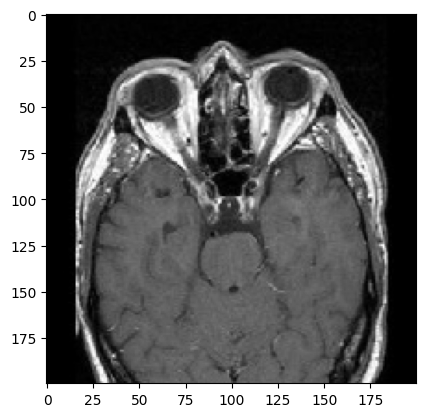

In [75]:
#Visualize Data - To check particular image
plt.imshow(X[0],cmap='gray')

In [76]:
#Prepare Data
X_updated = X.reshape(len(X),-1)
X_updated.shape

(2870, 40000)

In [77]:
#Split Data
xtrain, xtest, ytrain, ytest = train_test_split(X_updated, Y, random_state=10,test_size=.20)

In [78]:
xtrain.shape, xtest.shape

((2296, 40000), (574, 40000))

In [79]:
#Feature Scaling
print(xtrain.max(), xtrain.min())
print(xtest.max(), xtest.min())
xtrain = xtrain/255
xtest = xtest/255
print(xtrain.max(), xtrain.min())
print(xtest.max(), xtest.min())

255 0
255 0
1.0 0.0
1.0 0.0


In [80]:
#Feature Selection : PCA
from sklearn.decomposition import PCA
print(xtrain.shape, xtest.shape)

pca = PCA(.98)
# pca_train = pca.fit_transform(xtrain)
# pca_test = pca.transform(xtest)
pca_train = xtrain
pca_test = xtest

(2296, 40000) (574, 40000)


In [81]:
#Train Model
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

lg = LogisticRegression(C=0.1)
lg.fit(pca_train, ytrain)

LogisticRegression(C=0.1)

In [ ]:
sv = SVC()
sv.fit(pca_train, ytrain)

In [29]:
#Evaluation 
print("Training Score : ", lg.score(pca_train, ytrain))
print("Testing Score : ", lg.score(pca_test, ytest))

Training Score :  1.0
Testing Score :  0.9407665505226481


In [30]:
print("Training Score : ", sv.score(pca_train, ytrain))
print("Testing Score : ", sv.score(pca_test, ytest))

Training Score :  0.9804006968641115
Testing Score :  0.9442508710801394


In [31]:
#Prediction
pred = sv.predict(pca_test)
np.where(ytest!=pred)

(array([  9,  32,  37,  76, 125, 129, 140, 146, 149, 151, 166, 174, 181,
        187, 203, 242, 313, 338, 356, 375, 423, 438, 441, 448, 453, 466,
        474, 476, 501, 512, 513, 522], dtype=int64),)

In [34]:
pred[149]

1

ValueError: x and y must be the same size

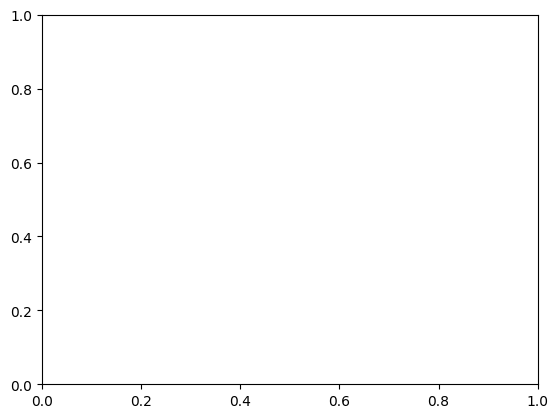

In [42]:
# plt.scatter(X,Y,c=Y,cmap='rainbow')
# plt.title('Scatter Plot')
# plt.show()

In [43]:
#Test Model
dec = {0:'no_tumor' , 1:'positive_tumor'}

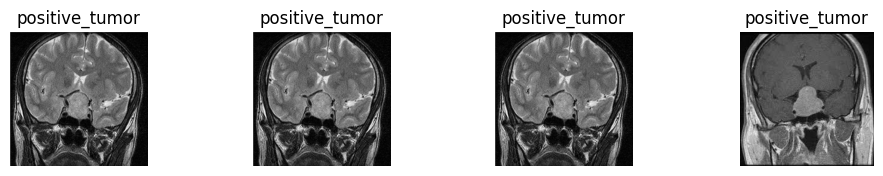

In [67]:
plt.figure(figsize=(12,8))
p = os.listdir('C:/Users/abhis/OneDrive/Desktop/TRANSFERED DATA/Data From other PC-1/Desktop/TE-Project/DataSet/Testing')
c=1
for i in os.listdir('C:/Users/abhis/OneDrive/Desktop/TRANSFERED DATA/Data From other PC-1/Desktop/TE-Project/DataSet/Testing/unseen/')[:16]:
    plt.subplot(4,4,c)
    
    img = cv2.imread('C:/Users/abhis/OneDrive/Desktop/TRANSFERED DATA/Data From other PC-1/Desktop/TE-Project/DataSet/Testing/unseen/'+i,0)
    img1 = cv2.resize(img, (200,200))
    img1 = img1.reshape(1,-1)/255
    p = lg.predict(img1)
#     p = sv.predict(img1)
    plt.title(dec[p[0]])
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1